In [20]:
# imports
# !pip install graphviz
from graphviz import Digraph

# given a graph, return a set of nodes and edges



In [21]:
# Value class

# what do we actually want out of this thing again??


class Value:
    def __init__(self, d, _children=(), lb=''):
        self._backward = lambda: None
        self._prev = set(_children) # done for efficiency (??? but you iterate over it so really who gaf) 
        self.data = d
        self.grad = 0.0
        self._op = ''
        self.label = lb

    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data + other.data, (self, other))
        def _backwards():
            # if f = a + b, df/da = 1 and df/db = 1, and * out.grad because chain rule (d(something else)/da = d(something else)/df * df/da)
            # += and not = because what if f = a + a? want df/da to be 2, not 1, and in the non-duplicate case += only happens once so equivalent to =
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backwards
        out._op = '+'
        return out

    def __neg__(self):
        out = Value(self.data *-1, (self,))
        def _backwards():
            # if f = a - b, df/da = 1 and df/db = - 1
            self.grad += -1.0 * out.grad
        out._backward = _backwards
        out._op = '-'
        return out

    def __sub__(self, other):
        return self + other.__neg__()

    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data * other.data, (self, other))
        def _backwards():
            # if f = a*b, df/da = b and df/db = a
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backwards
        out._op = '*'
        return out
    
    # when we try to do 2.__add__(a) it will freak out and check if a has rmul to call so this is for that
    def __rmul__(self, other):
        return self.__mul__(other)


In [22]:
# trying to visualize the graph using just the graphviz docs lmao

def get_V_and_E_from_value_obj(v):
    # wait gang this is just bf/dfs?? no one gaf?? just add yourself and then add your children
    V = set()
    E = set()
    
    def add_node_and_kids(vertex):
        if vertex not in V:
            V.add(vertex)
            for kid in vertex._prev:
                E.add((kid, vertex))
                add_node_and_kids(kid)
    
    add_node_and_kids(v)
    return V, E

# this part i did refer to the draw_dot function but only for syntax!
def draw_expr_graph(value):
    g = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    vertices, edges = get_V_and_E_from_value_obj(value)
    for vertex in vertices:
        uid = str(id(vertex))
        g.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (vertex.label, vertex.data, vertex.grad), shape='record')
        if vertex._op:
            g.node(name=uid + vertex._op, label=vertex._op)
            g.edge(uid + vertex._op, uid)
    
    for source, target in edges:
        if target._op:
            g.edge(str(id(source)), str(id(target)) + target._op)
    
    return g
        



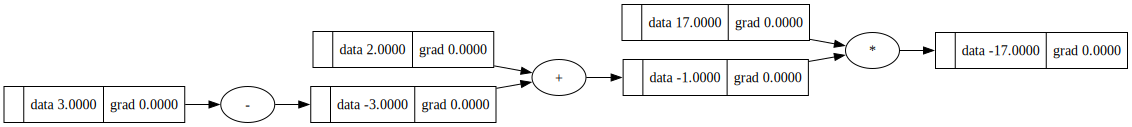

In [23]:
a = Value(2.0)
b = Value(3.0)
c = a - b
f = Value(17.0)
d = f*c
draw_expr_graph(d)


In [ ]:
# sample expression

In [ ]:
# "gradient checks"